###Load and Explore Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [ ]:
airline_data = pd.read_csv('/content/drive/MyDrive/Case Studies/United Airlines/dataset/airline_maintenance.csv')

In [ ]:
df = airline_data.copy()
df.head()

,flight_id,aircraft_id,flight_hours,flight_cycles,engine_temp,vibration_level,oil_pressure,fuel_flow,cabin_pressure,route_type,avg_weather_temp,turbulence,airport_condition,last_maintenance_days,maintenance_score,failure_within_30_days
0,1,AC_103,307,100,863.51,1.23,43.10,6074.29,12.67,Domestic,17.74,0,0.64,123,0.60,0
1,2,AC_180,371,78,765.82,1.86,54.47,6423.24,12.30,Long-haul,5.26,0,0.06,103,0.46,1
2,3,AC_93,214,270,894.46,2.00,60.74,5694.91,11.35,Domestic,-1.77,5,0.66,156,0.64,0
3,4,AC_15,261,183,860.48,1.45,52.37,6198.98,10.16,Domestic,19.30,0,0.69,25,0.91,0
4,5,AC_107,345,81,935.12,1.77,55.67,3752.87,12.65,Domestic,8.79,4,0.52,118,0.51,0


In [ ]:
df.shape

(50000, 16)

In [ ]:
#Target Distribution
failure_rate = df['failure_within_30_days'].mean()
print(f" Failure Rate: {failure_rate:.2%} ({df['failure_within_30_days'].sum()} failures out of {len(df)})")

 Failure Rate: 5.76% (2882 failures out of 50000)


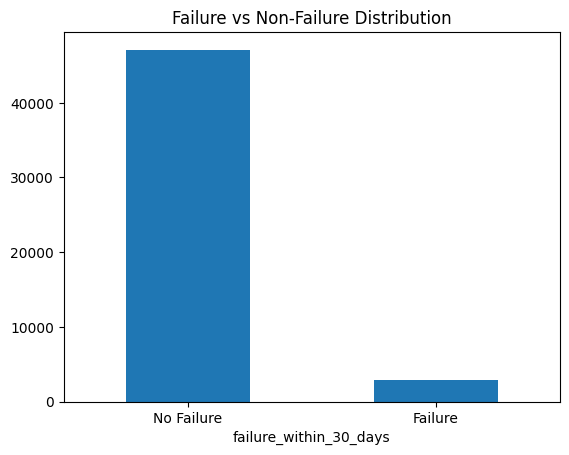

In [ ]:
#Check failures vs non-failures
df['failure_within_30_days'].value_counts().plot(kind='bar')
plt.title("Failure vs Non-Failure Distribution")
plt.xticks([0,1], ['No Failure', 'Failure'], rotation=0)
plt.show()

In [ ]:
#Summary of numerical features
df.describe()

,flight_id,flight_hours,flight_cycles,engine_temp,vibration_level,oil_pressure,fuel_flow,cabin_pressure,avg_weather_temp,turbulence,airport_condition,last_maintenance_days,maintenance_score,failure_within_30_days
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,25000.500000,299.41266,150.132400,850.092859,1.506822,49.990781,4996.919990,11.994268,7.548922,1.746800,0.499199,90.13414,0.700429,0.057640
std,14433.901067,173.09557,86.888416,50.026338,0.680708,9.985429,1201.743207,1.003108,21.595925,1.482354,0.288531,51.81866,0.173178,0.233064
min,1.000000,0.00000,0.000000,650.030000,0.000000,5.860000,-285.060000,7.750000,-30.000000,0.000000,0.000000,1.00000,0.400000,0.000000
25%,12500.750000,150.00000,75.000000,816.390000,1.030000,43.250000,4186.080000,11.320000,-11.140000,0.000000,0.250000,45.00000,0.550000,0.000000
50%,25000.500000,299.00000,150.000000,849.960000,1.500000,50.020000,4992.770000,11.990000,7.460000,1.000000,0.500000,90.00000,0.700000,0.000000
75%,37500.250000,448.00000,226.000000,883.810000,1.970000,56.750000,5805.330000,12.670000,26.320000,3.000000,0.750000,135.00000,0.850000,0.000000
max,50000.000000,600.00000,300.000000,1078.110000,4.280000,87.820000,10063.240000,15.920000,45.000000,5.000000,1.000000,180.00000,1.000000,1.000000


In [ ]:
#Summary if categorical features
df.select_dtypes(include=['object']).describe()

,aircraft_id,route_type
count,50000,50000
unique,200,3
top,AC_87,Domestic
freq,302,24733


In [ ]:
#Check for columns with 0
df.columns[df.eq(0).any()]

Index(['flight_hours', 'flight_cycles', 'vibration_level', 'avg_weather_temp',
       'turbulence', 'airport_condition', 'failure_within_30_days'],
      dtype='object')